# 05b — Exercises: PyTorch Fundamentals & Tensors

---


## Exercise 1 — Tensors
Create a `(4, 4)` tensor of random integers between 0 and 9. Extract the diagonal. Compute the row-wise mean.


In [1]:
import torch

torch.manual_seed(42)

# Create a (4, 4) tensor of random integers in [0, 9]
t = torch.randint(low=0, high=10, size=(4, 4))
print("Original tensor:")
print(t)

# Extract the diagonal (the 4 elements t[0,0], t[1,1], t[2,2], t[3,3])
diagonal = torch.diag(t)
print("\nDiagonal elements:", diagonal)

# Compute row-wise mean
# dim=1 means we reduce along columns → one mean value per row
row_means = t.float().mean(dim=1)   # .float() needed because integers can't be averaged directly
print("\nRow-wise means:", row_means)
print("  Row 0 mean:", row_means[0].item())
print("  Row 1 mean:", row_means[1].item())
print("  Row 2 mean:", row_means[2].item())
print("  Row 3 mean:", row_means[3].item())


Original tensor:
tensor([[2, 7, 6, 4],
        [6, 5, 0, 4],
        [0, 3, 8, 4],
        [0, 4, 1, 2]])

Diagonal elements: tensor([2, 5, 8, 2])

Row-wise means: tensor([4.7500, 3.7500, 3.7500, 1.7500])
  Row 0 mean: 4.75
  Row 1 mean: 3.75
  Row 2 mean: 3.75
  Row 3 mean: 1.75


## Exercise 2 — Build an `nn.Module` with 3 Hidden Layers
Build a model with 3 hidden layers of your choice. Print the total parameter count. Run a random batch through it.


In [2]:
import torch.nn as nn

class ThreeLayerNet(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        # Hidden layer 1: input → 64 neurons
        self.layer1 = nn.Linear(input_size, 64)
        self.relu1  = nn.ReLU()

        # Hidden layer 2: 64 → 32 neurons
        self.layer2 = nn.Linear(64, 32)
        self.relu2  = nn.ReLU()

        # Hidden layer 3: 32 → 16 neurons
        self.layer3 = nn.Linear(32, 16)
        self.relu3  = nn.ReLU()

        # Output layer: 16 → output
        self.output = nn.Linear(16, output_size)

    def forward(self, x):
        x = self.relu1(self.layer1(x))   # hidden layer 1
        x = self.relu2(self.layer2(x))   # hidden layer 2
        x = self.relu3(self.layer3(x))   # hidden layer 3
        x = self.output(x)               # output layer
        return x


# Instantiate: 10 input features, 3 output classes
model = ThreeLayerNet(input_size=10, output_size=3)
print(model)

# Count total parameters
# Each nn.Linear(in, out) has (in × out) weights + out biases
total_params = sum(p.numel() for p in model.parameters())
print(f"\nParameter breakdown:")
for name, p in model.named_parameters():
    print(f"  {name:<20} shape={str(p.shape):<20} → {p.numel()} params")
print(f"\nTotal parameters: {total_params:,}")

# Run a random batch through the model
batch_size = 8
x_random = torch.randn(batch_size, 10)   # 8 samples, 10 features each
output = model(x_random)

print(f"\nInput shape:  {x_random.shape}")
print(f"Output shape: {output.shape}    ← 8 samples, 3 class logits each")
print(f"\nRaw logits (first 3 samples):\n{output[:3].detach().numpy().round(3)}")


ThreeLayerNet(
  (layer1): Linear(in_features=10, out_features=64, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=32, out_features=16, bias=True)
  (relu3): ReLU()
  (output): Linear(in_features=16, out_features=3, bias=True)
)

Parameter breakdown:
  layer1.weight        shape=torch.Size([64, 10]) → 640 params
  layer1.bias          shape=torch.Size([64])     → 64 params
  layer2.weight        shape=torch.Size([32, 64]) → 2048 params
  layer2.bias          shape=torch.Size([32])     → 32 params
  layer3.weight        shape=torch.Size([16, 32]) → 512 params
  layer3.bias          shape=torch.Size([16])     → 16 params
  output.weight        shape=torch.Size([3, 16])  → 48 params
  output.bias          shape=torch.Size([3])      → 3 params

Total parameters: 3,363

Input shape:  torch.Size([8, 10])
Output shape: torch.Size([8, 3])    ← 8 samples, 3 class logits each

Raw logits (first 3 samples

## Exercise 3 — Effect of Learning Rate on Training
Train the same model twice — once with `lr=0.1` and once with `lr=0.0001` — and plot both loss curves.


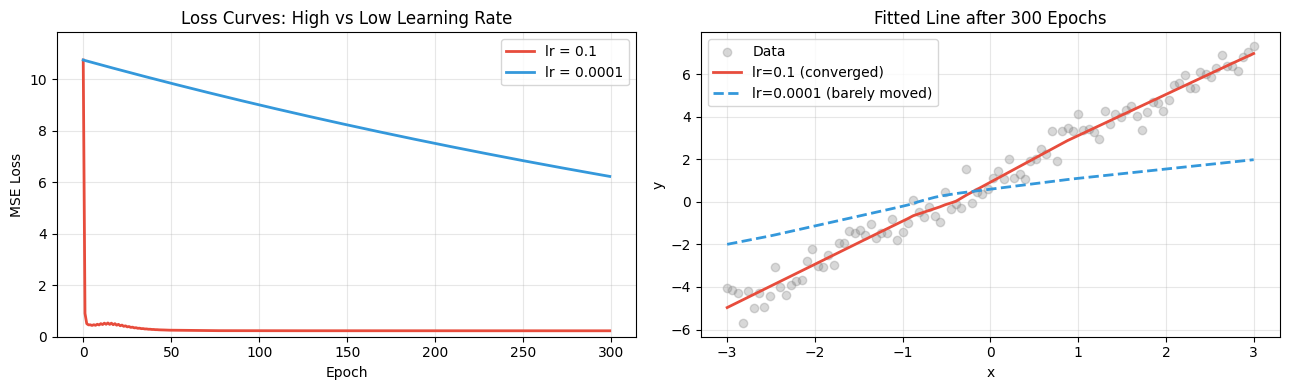

lr=0.1    — final loss: 0.2301
lr=0.0001 — final loss: 6.2279


In [3]:
import matplotlib.pyplot as plt
import torch.optim as optim

torch.manual_seed(42)

# ── Synthetic data: y = 2x + 1 + noise ──
X = torch.linspace(-3, 3, 100).unsqueeze(1)   # shape (100, 1)
y = 2 * X + 1 + 0.5 * torch.randn_like(X)     # shape (100, 1)

def train(lr, n_epochs=300):
    """Train a small regression model and return the loss history."""
    # Fresh model for each run so results are independent
    torch.manual_seed(0)
    model = nn.Sequential(
        nn.Linear(1, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    losses = []
    for epoch in range(n_epochs):
        optimizer.zero_grad()          # clear gradients from previous step
        predictions = model(X)        # forward pass
        loss = criterion(predictions, y)  # compute loss
        loss.backward()               # backprop
        optimizer.step()              # update weights
        losses.append(loss.item())    # record scalar loss value

    return losses, model


# ── Train with two different learning rates ──
losses_high, model_high = train(lr=0.1)
losses_low,  model_low  = train(lr=0.0001)

# ── Plot loss curves ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(losses_high, color='#E74C3C', lw=2, label='lr = 0.1')
axes[0].plot(losses_low,  color='#3498DB', lw=2, label='lr = 0.0001')
axes[0].set_title("Loss Curves: High vs Low Learning Rate")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, max(losses_low[0], losses_high[0]) * 1.1)

# ── Plot fitted lines ──
axes[1].scatter(X.numpy(), y.numpy(), alpha=0.3, color='gray', label='Data')

with torch.no_grad():
    axes[1].plot(X.numpy(), model_high(X).numpy(),
                 color='#E74C3C', lw=2, label='lr=0.1 (converged)')
    axes[1].plot(X.numpy(), model_low(X).numpy(),
                 color='#3498DB', lw=2, label='lr=0.0001 (barely moved)', linestyle='--')

axes[1].set_title("Fitted Line after 300 Epochs")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"lr=0.1    — final loss: {losses_high[-1]:.4f}")
print(f"lr=0.0001 — final loss: {losses_low[-1]:.4f}")


### What do you see?

**`lr = 0.1` (red):**
The loss drops quickly and converges to a low value within the first ~50 epochs. The fitted line closely follows the data. This is a well-chosen learning rate for this problem.

**`lr = 0.0001` (blue):**
The loss barely decreases in 300 epochs — the weight updates are so tiny that the model has almost no time to learn anything useful. The fitted line is nearly flat. Given enough epochs (tens of thousands), it would eventually converge to the same solution, but it is impractically slow.

**Key takeaway:** The learning rate controls *how big a step* the optimizer takes at each update. Too small → painfully slow. Too large → can overshoot and diverge. In practice, start around `0.001` (Adam) or `0.01` (SGD) and adjust based on the loss curve.
